# SE-ResNeXt-50 Multiscale Native-CAM + EMA Experiment

This notebook evaluates one controlled candidate against the completed `12x12`
SE-ResNeXt baseline: a faithful `24x24` multiscale native-CAM head with
exponential-moving-average (EMA) checkpoint evaluation. The dataset split, CE
loss, sampler, transforms, stage schedule, learning rates, and validation
selection score remain unchanged, so the comparison isolates the architecture
and weight averaging.

The five fused spatial class maps are globally averaged to obtain the five CE
logits. Consequently, every displayed map remains part of the classifier's
forward computation. This is an experiment and must pass both validation and
CAM gates before its checkpoint is used by the application.

The completed baseline remains archived at
`docs/report/se_resnext50_32x4d/2026-07-23_01-25-36_seresnext50_32x4d_final_native_cam_ce.ipynb`.

## Execution

Run every cell from top to bottom in a fresh Colab GPU runtime. The dataset is
extracted from Drive when the archive exists. The notebook trains on `train`,
selects checkpoints only on `val`, and evaluates `test` once after selection.


In [ ]:
import copy
import csv
import hashlib
import json
import os
import random
import subprocess
from collections import Counter
from datetime import datetime, timezone
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms as transforms
import tqdm
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    precision_recall_fscore_support,
    recall_score,
    roc_auc_score,
)
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler

try:
    from google.colab import drive
    drive.mount("/content/drive")
except ImportError:
    print("Not running in Colab; Drive mount skipped.")

try:
    import timm
except ImportError:
    subprocess.run(["pip", "install", "-q", "timm"], check=True)
    import timm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

SEED = 42
EMA_DECAY = 0.999
ARCHITECTURE = "multiscale24_native_cam_ce_ema"
BATCH_SIZE = 48

# Exact gates from the completed 2026-07-23 01:25:36.772175 UTC baseline.
BASELINE_VALIDATION = {
    "qwk": 0.7873319830602099,
    "macro_f1": 0.6497842097059795,
    "grade1_recall": 0.41830065359477125,
    "macro_ap": 0.6915474596314173,
    "macro_auc": 0.8752130998574217,
    "selection_score": 0.7002724504801549,
}
BASELINE_TEST = {
    "accuracy": 0.6388888888888888,
    "qwk": 0.819420698214893,
    "macro_f1": 0.6671330191376962,
    "grade1_recall": 0.4155405405405405,
    "macro_ap": 0.7248023848112104,
    "macro_auc": 0.8948276065375278,
}
BASELINE_CAM = {
    "joint_energy": 0.8706657083596738,
    "border_energy": 0.07487359307599288,
    "lower_tibia_energy": 0.08799615740717395,
    "peak_inside_joint_rate": 0.9955947136563876,
    "source_resolution": 12,
}

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

dataset_zip = Path("/content/drive/MyDrive/Datasets/kaggle_knee_osteoarthritis.zip")
if dataset_zip.exists():
    subprocess.run(
        ["unzip", "-q", "-o", str(dataset_zip), "-d", "/content/Datasets"],
        check=True,
    )

DATASET_ROOT = Path("/content/Datasets/kaggle_knee_osteoarthritis")
RUN_TIMESTAMP = datetime.now(timezone.utc).strftime(
    "%Y-%m-%d_%H-%M-%S_%f_UTC"
)
RUN_DIR = (
    Path("/content/drive/MyDrive/Models/seresnext50_32x4d_checkpoints")
    / f"{RUN_TIMESTAMP}_{ARCHITECTURE}"
)
RUN_DIR.mkdir(parents=True, exist_ok=False)
print(f"Run directory: {RUN_DIR}")

Mounted at /content/drive
Device: cuda
GPU: Tesla T4
Run directory: /content/drive/MyDrive/Models/seresnext50_32x4d_checkpoints/2026-07-23_06-57-13_378879_UTC_multiscale24_native_cam_ce_ema


## Data Preparation

Images are deduplicated across splits. Right knees are mirrored so every image
follows the same medial/lateral convention. Training uses mild rotation,
brightness/contrast jitter, one small random erase, and full inverse-frequency
sampling. Validation and test preprocessing are deterministic.


In [ ]:
class SquarePad:
    def __call__(self, image):
        height, width = image.shape[:2]
        side = max(height, width)
        top = (side - height) // 2
        bottom = side - height - top
        left = (side - width) // 2
        right = side - width - left
        return cv2.copyMakeBorder(
            image,
            top,
            bottom,
            left,
            right,
            cv2.BORDER_CONSTANT,
            value=[0, 0, 0],
        )


class CLAHE:
    def __call__(self, image):
        lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
        lightness, channel_a, channel_b = cv2.split(lab)
        lightness = cv2.createCLAHE(
            clipLimit=2.0, tileGridSize=(8, 8)
        ).apply(lightness)
        return cv2.cvtColor(
            cv2.merge((lightness, channel_a, channel_b)),
            cv2.COLOR_LAB2RGB,
        )


train_transform = transforms.Compose([
    SquarePad(),
    CLAHE(),
    transforms.ToPILImage(),
    transforms.RandomRotation(5),
    transforms.ColorJitter(brightness=0.08, contrast=0.08),
    transforms.Resize((400, 400)),
    transforms.RandomCrop(384),
    transforms.ToTensor(),
    transforms.RandomErasing(
        p=0.10, scale=(0.02, 0.05), ratio=(0.5, 2.0), value=0
    ),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

evaluation_transform = transforms.Compose([
    SquarePad(),
    CLAHE(),
    transforms.ToPILImage(),
    transforms.Resize((400, 400)),
    transforms.CenterCrop(384),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])


def file_digest(path):
    digest = hashlib.sha256()
    with open(path, "rb") as image_file:
        for chunk in iter(lambda: image_file.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


class KneeDataset(Dataset):
    def __init__(self, split, transform, excluded_hashes=None):
        self.transform = transform
        split_dir = DATASET_ROOT / split
        if not split_dir.is_dir():
            raise FileNotFoundError(f"Dataset split is missing: {split_dir}")

        excluded_hashes = excluded_hashes or set()
        retained_hashes = set()
        self.paths = []
        self.labels = []
        for grade in range(5):
            grade_dir = split_dir / str(grade)
            for path in sorted(grade_dir.iterdir()):
                if path.suffix.lower() not in {".png", ".jpg", ".jpeg"}:
                    continue
                digest = file_digest(path)
                if digest in excluded_hashes or digest in retained_hashes:
                    continue
                retained_hashes.add(digest)
                self.paths.append(str(path))
                self.labels.append(grade)
        self.image_hashes = retained_hashes
        print(f"{split}: {len(self.paths)} unique images")

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, index):
        path = self.paths[index]
        image = cv2.imread(path)
        if image is None:
            raise IOError(f"Could not read image: {path}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        if Path(path).stem.upper().endswith("R"):
            image = np.ascontiguousarray(image[:, ::-1])
        return self.transform(image), self.labels[index], path


In [ ]:
train_dataset = KneeDataset("train", train_transform)
validation_dataset = KneeDataset(
    "val", evaluation_transform, train_dataset.image_hashes
)

class_counts = Counter(train_dataset.labels)
sample_weights = [
    1.0 / class_counts[label] for label in train_dataset.labels
]
sampler_generator = torch.Generator().manual_seed(SEED)
balanced_sampler = WeightedRandomSampler(
    sample_weights,
    num_samples=len(sample_weights),
    replacement=True,
    generator=sampler_generator,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=balanced_sampler,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    generator=sampler_generator,
)
validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
)
print("Class counts:", dict(sorted(class_counts.items())))
print(
    f"Batches: train={len(train_loader)}, "
    f"validation={len(validation_loader)}"
)

train: 5778 unique images
val: 826 unique images
Class counts: {0: 2286, 1: 1046, 2: 1516, 3: 757, 4: 173}
Batches: train=121, validation=18


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


## Model: `multiscale24_native_cam_ce_ema`

The backbone returns its `24x24` penultimate and `12x12` final tensors. Separate
1x1 convolutions convert both scales directly into five grade maps. Only the five
final-scale maps are upsampled, then the two scales are averaged. Global spatial
averaging of the fused `24x24` maps produces the logits exactly.

EMA weights are updated after every optimizer step and are the weights evaluated
for validation and saved as candidate checkpoints. Raw weights are retained only
in the last checkpoint for debugging.

In [ ]:
class SEResNeXt50MultiScaleNativeCAM(nn.Module):
    """Faithful 24x24 native CAM from linear class maps at two backbone scales."""

    def __init__(self, pretrained=True):
        super().__init__()
        self.backbone = timm.create_model(
            "seresnext50_32x4d",
            pretrained=pretrained,
            features_only=True,
            out_indices=(3, 4),
        )
        stage3_channels, stage4_channels = self.backbone.feature_info.channels()
        self.stage3_class_conv = nn.Conv2d(stage3_channels, 5, kernel_size=1)
        self.stage4_class_conv = nn.Conv2d(stage4_channels, 5, kernel_size=1)

    def head_parameters(self):
        return list(self.stage3_class_conv.parameters()) + list(
            self.stage4_class_conv.parameters()
        )

    def class_maps(self, images):
        stage3_features, stage4_features = self.backbone(images)
        stage3_maps = self.stage3_class_conv(stage3_features)
        stage4_maps = self.stage4_class_conv(stage4_features)
        stage4_maps = F.interpolate(
            stage4_maps,
            size=stage3_maps.shape[-2:],
            mode="bilinear",
            align_corners=False,
        )
        return 0.5 * (stage3_maps + stage4_maps)

    def forward(self, images):
        return self.class_maps(images).mean(dim=(2, 3))

    def native_cam(self, images, class_indices=None):
        with torch.no_grad():
            maps = self.class_maps(images)
            logits = maps.mean(dim=(2, 3))
            if class_indices is None:
                class_indices = logits.argmax(dim=1)
            class_indices = torch.as_tensor(
                class_indices, device=images.device, dtype=torch.long
            ).reshape(-1)
            selected = maps[
                torch.arange(images.size(0), device=images.device),
                class_indices,
            ]
            selected = F.relu(selected).unsqueeze(1)
            selected = F.interpolate(
                selected,
                size=images.shape[-2:],
                mode="bilinear",
                align_corners=False,
            ).squeeze(1)
            maxima = selected.flatten(1).amax(1).clamp_min(1e-8)
            selected = selected / maxima[:, None, None]
        return selected, logits

    def freeze_backbone(self):
        for parameter in self.backbone.parameters():
            parameter.requires_grad = False
        for parameter in self.head_parameters():
            parameter.requires_grad = True

    def unfreeze_final_stages(self):
        for parameter in self.parameters():
            parameter.requires_grad = False
        matched = 0
        for name, parameter in self.backbone.named_parameters():
            if any(
                token in name
                for token in ("layer3", "layer4", "stages.2", "stages.3")
            ):
                parameter.requires_grad = True
                matched += parameter.numel()
        if matched == 0:
            raise RuntimeError("Could not resolve the final backbone stages.")
        for parameter in self.head_parameters():
            parameter.requires_grad = True

    def unfreeze_all(self):
        for parameter in self.parameters():
            parameter.requires_grad = True


class ModelEMA:
    """Maintain an inference-only exponential moving average of model state."""

    def __init__(self, model, decay=0.999):
        if not 0.0 < decay < 1.0:
            raise ValueError("EMA decay must be between 0 and 1.")
        self.decay = float(decay)
        self.module = copy.deepcopy(model).eval()
        self.module.requires_grad_(False)

    @torch.no_grad()
    def update(self, model):
        source_state = model.state_dict()
        for name, averaged_value in self.module.state_dict().items():
            source_value = source_state[name].detach()
            if averaged_value.is_floating_point():
                averaged_value.mul_(self.decay).add_(
                    source_value, alpha=1.0 - self.decay
                )
            else:
                averaged_value.copy_(source_value)

    @torch.no_grad()
    def reset(self, model):
        self.module.load_state_dict(model.state_dict())
        self.module.eval()

## Training and Validation

Training retains the baseline's three stages: five head-only epochs, fifteen
final-stage epochs, and ten full fine-tuning epochs. After each optimizer step,
EMA is updated with decay `0.999`. Only EMA weights are evaluated for checkpoint
selection. The composite score uses validation QWK, macro F1/recall, Grade 1
recall, AP, and AUC; the test split is never used for optimization.

In [ ]:
def calculate_metrics(labels, predictions, probabilities):
    labels = np.asarray(labels)
    predictions = np.asarray(predictions)
    probabilities = np.asarray(probabilities)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, labels=[0, 1, 2, 3, 4],
        average="macro", zero_division=0
    )
    one_hot = np.eye(5)[labels]
    metrics = {
        "accuracy": float(accuracy_score(labels, predictions)),
        "qwk": float(cohen_kappa_score(labels, predictions, weights="quadratic")),
        "macro_precision": float(precision),
        "macro_recall": float(recall),
        "macro_f1": float(f1),
        "grade1_recall": float(
            recall_score(labels == 1, predictions == 1, zero_division=0)
        ),
        "macro_ap": float(
            average_precision_score(one_hot, probabilities, average="macro")
        ),
        "macro_auc": float(
            roc_auc_score(one_hot, probabilities, average="macro")
        ),
    }
    metrics["selection_score"] = float(
        0.40 * metrics["qwk"]
        + 0.20 * metrics["macro_f1"]
        + 0.10 * metrics["macro_recall"]
        + 0.10 * metrics["grade1_recall"]
        + 0.15 * metrics["macro_ap"]
        + 0.05 * metrics["macro_auc"]
    )
    return metrics


def train_one_epoch(model, ema, loader, optimizer, scaler, description):
    model.train()
    running_loss = 0.0
    for images, labels, _ in tqdm.tqdm(loader, desc=description, leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(
            device_type=device.type,
            enabled=device.type == "cuda",
        ):
            loss = F.cross_entropy(model(images), labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        ema.update(model)
        running_loss += loss.item() * labels.size(0)
    return running_loss / len(loader.dataset)


def evaluate(model, loader, description):
    model.eval()
    labels_all, predictions_all, probabilities_all, paths_all = [], [], [], []
    total_loss = 0.0
    with torch.no_grad():
        for images, labels, paths in tqdm.tqdm(loader, desc=description, leave=False):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            logits = model(images)
            probabilities = F.softmax(logits.float(), dim=1)
            total_loss += F.cross_entropy(logits, labels).item() * labels.size(0)
            labels_all.extend(labels.cpu().numpy())
            predictions_all.extend(probabilities.argmax(1).cpu().numpy())
            probabilities_all.extend(probabilities.cpu().numpy())
            paths_all.extend(paths)
    metrics = calculate_metrics(
        labels_all, predictions_all, probabilities_all
    )
    metrics["loss"] = total_loss / len(loader.dataset)
    return (
        metrics,
        np.asarray(labels_all),
        np.asarray(predictions_all),
        np.asarray(probabilities_all),
        paths_all,
    )


def load_checkpoint(path):
    try:
        return torch.load(path, map_location=device, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=device)

In [ ]:
model = SEResNeXt50MultiScaleNativeCAM(pretrained=True).to(device)
ema = ModelEMA(model, decay=EMA_DECAY)
scaler = torch.amp.GradScaler("cuda", enabled=device.type == "cuda")
stage2_path = RUN_DIR / "stage2_best_model.pth"
best_path = RUN_DIR / "best_model.pth"
last_path = RUN_DIR / "last_model.pth"
history = []
best_stage2_score = -float("inf")
best_final_score = -float("inf")
global_epoch = 0

for stage_name, stage_epochs in (("warmup", 5), ("coarse", 15), ("finetune", 10)):
    if stage_name == "warmup":
        model.freeze_backbone()
        optimizer = optim.AdamW(
            model.head_parameters(), lr=3e-4, weight_decay=1e-4
        )
        scheduler = None
    elif stage_name == "coarse":
        model.unfreeze_final_stages()
        optimizer = optim.AdamW(
            [
                {
                    "params": [
                        parameter for parameter in model.backbone.parameters()
                        if parameter.requires_grad
                    ],
                    "lr": 3e-5,
                },
                {"params": model.head_parameters(), "lr": 3e-4},
            ],
            weight_decay=1e-4,
        )
        scheduler = optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=15, eta_min=1e-7
        )
    else:
        if not stage2_path.exists():
            raise FileNotFoundError("Stage 2 did not produce a checkpoint.")
        model.load_state_dict(load_checkpoint(stage2_path)["model_state_dict"])
        ema.reset(model)
        model.unfreeze_all()
        optimizer = optim.AdamW(
            model.parameters(), lr=1e-5, weight_decay=1e-3
        )
        scheduler = optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=10, eta_min=1e-7
        )

    for stage_epoch in range(stage_epochs):
        global_epoch += 1
        train_loss = train_one_epoch(
            model,
            ema,
            train_loader,
            optimizer,
            scaler,
            f"{stage_name} {stage_epoch + 1}/{stage_epochs}",
        )
        validation_metrics, _, _, _, _ = evaluate(
            ema.module, validation_loader, "VALIDATE EMA"
        )
        history.append({
            "epoch": global_epoch,
            "stage": stage_name,
            "train_loss": train_loss,
            **validation_metrics,
        })
        print(
            f"Epoch {global_epoch:02d} | {stage_name} | EMA | "
            f"QWK={validation_metrics['qwk']:.4f} | "
            f"F1={validation_metrics['macro_f1']:.4f} | "
            f"G1R={validation_metrics['grade1_recall']:.4f} | "
            f"AP={validation_metrics['macro_ap']:.4f} | "
            f"selection={validation_metrics['selection_score']:.4f}"
        )
        if scheduler is not None:
            scheduler.step()

        candidate_payload = {
            "model_state_dict": ema.module.state_dict(),
            "epoch": global_epoch,
            "stage": stage_name,
            "architecture": ARCHITECTURE,
            "model_name": "seresnext50_32x4d",
            "loss_type": "ce",
            "validation_metrics": validation_metrics,
            "history": history,
            "run_timestamp": RUN_TIMESTAMP,
            "ema_decay": EMA_DECAY,
            "experimental_config": {
                "input_resize": 400,
                "input_crop": 384,
                "batch_size": BATCH_SIZE,
                "sampler": "full_inverse_frequency",
                "canonicalize_laterality": True,
                "stage_epochs": [5, 15, 10],
                "learning_rates": [3e-4, 3e-5, 1e-5],
                "native_cam_source_resolution": 24,
                "multiscale_feature_indices": [3, 4],
                "ema_decay": EMA_DECAY,
            },
        }
        if (
            stage_name == "coarse"
            and validation_metrics["selection_score"] > best_stage2_score
        ):
            best_stage2_score = validation_metrics["selection_score"]
            torch.save(candidate_payload, stage2_path)
        if (
            stage_name == "finetune"
            and validation_metrics["selection_score"] > best_final_score
        ):
            best_final_score = validation_metrics["selection_score"]
            torch.save(candidate_payload, best_path)

        last_payload = dict(candidate_payload)
        last_payload["raw_model_state_dict"] = model.state_dict()
        torch.save(last_payload, last_path)

if not best_path.exists():
    raise RuntimeError("Training finished without a final checkpoint.")
with open(RUN_DIR / "epoch_metrics.csv", "w", newline="") as handle:
    writer = csv.DictWriter(handle, fieldnames=history[0].keys())
    writer.writeheader()
    writer.writerows(history)
print(f"Selected EMA checkpoint: {best_path}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


model.safetensors: reconstructing file:   0%|          |  0.00B /  111MB            

model.safetensors: downloading bytes:           |  0.00B            

warmup 1/5:   0%|          | 0/121 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch 01 | warmup | EMA | QWK=0.0029 | F1=0.0385 | G1R=0.0000 | AP=0.2012 | selection=0.0840


...

Epoch 26 | finetune | EMA | QWK=0.6903 | F1=0.5911 | G1R=0.5882 | AP=0.6508 | selection=0.6561


Epoch 27 | finetune | EMA | QWK=0.6888 | F1=0.5847 | G1R=0.5882 | AP=0.6519 | selection=0.6541


Epoch 28 | finetune | EMA | QWK=0.6997 | F1=0.5878 | G1R=0.5882 | AP=0.6543 | selection=0.6598


Epoch 29 | finetune | EMA | QWK=0.7082 | F1=0.5965 | G1R=0.5882 | AP=0.6569 | selection=0.6661


Epoch 30 | finetune | EMA | QWK=0.7150 | F1=0.6028 | G1R=0.6078 | AP=0.6573 | selection=0.6728
Selected EMA checkpoint: /content/drive/MyDrive/Models/seresnext50_32x4d_checkpoints/2026-07-23_06-57-13_378879_UTC_multiscale24_native_cam_ce_ema/best_model.pth


## Locked Test Evaluation

The test split is loaded only after the EMA checkpoint has been selected using
validation data. Test results are reported against the stored baseline but never
participate in checkpoint selection or the promotion decision.

test: 1656 unique images


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
TEST:   0%|          | 0/35 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality(

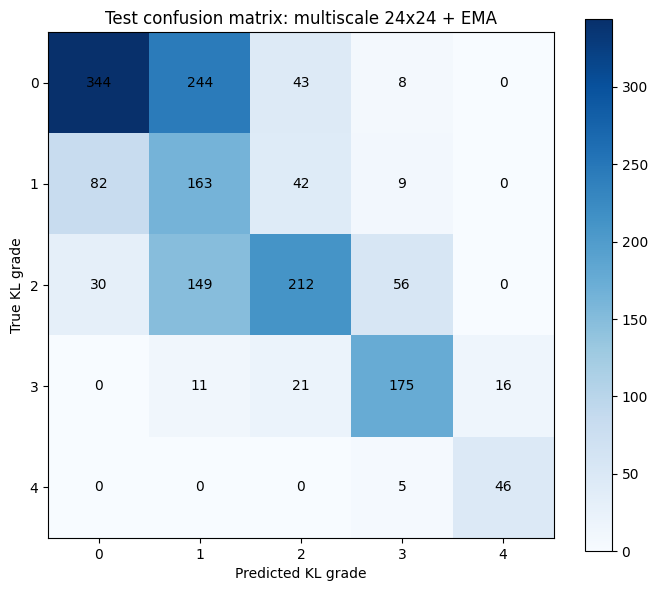

{
  "accuracy": 0.5676328502415459,
  "qwk": 0.7651199108537203,
  "macro_precision": 0.6284331348675238,
  "macro_recall": 0.6500007823852676,
  "macro_f1": 0.6219528611577199,
  "grade1_recall": 0.5506756756756757,
  "macro_ap": 0.6917632016403902,
  "macro_auc": 0.8703218274976938,
  "selection_score": 0.6977867540000697,
  "loss": 0.9259461246538854
}
              precision    recall  f1-score   support

     Grade 0       0.75      0.54      0.63       639
     Grade 1       0.29      0.55      0.38       296
     Grade 2       0.67      0.47      0.55       447
     Grade 3       0.69      0.78      0.74       223
     Grade 4       0.74      0.90      0.81        51

    accuracy                           0.57      1656
   macro avg       0.63      0.65      0.62      1656
weighted avg       0.64      0.57      0.58      1656



In [ ]:
test_dataset = KneeDataset(
    "test",
    evaluation_transform,
    train_dataset.image_hashes | validation_dataset.image_hashes,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
)

best_checkpoint = load_checkpoint(best_path)
model.load_state_dict(best_checkpoint["model_state_dict"])
model.eval()
test_metrics, test_true, test_predicted, test_probabilities, test_paths = evaluate(
    model, test_loader, "TEST"
)

prediction_rows = []
for path, true_grade, predicted_grade, probabilities in zip(
    test_paths, test_true, test_predicted, test_probabilities
):
    prediction_rows.append({
        "path": path,
        "true_grade": int(true_grade),
        "predicted_grade": int(predicted_grade),
        **{
            f"grade_{grade}_probability": float(probabilities[grade])
            for grade in range(5)
        },
    })
with open(RUN_DIR / "test_predictions.csv", "w", newline="") as handle:
    writer = csv.DictWriter(handle, fieldnames=prediction_rows[0].keys())
    writer.writeheader()
    writer.writerows(prediction_rows)
with open(RUN_DIR / "test_metrics.json", "w") as handle:
    json.dump(test_metrics, handle, indent=2)

matrix = confusion_matrix(test_true, test_predicted, labels=[0, 1, 2, 3, 4])
figure, axis = plt.subplots(figsize=(7, 6))
image = axis.imshow(matrix, cmap="Blues")
for row in range(5):
    for column in range(5):
        axis.text(column, row, matrix[row, column], ha="center", va="center")
axis.set(
    title="Test confusion matrix: multiscale 24x24 + EMA",
    xlabel="Predicted KL grade",
    ylabel="True KL grade",
    xticks=range(5),
    yticks=range(5),
)
figure.colorbar(image, ax=axis)
figure.tight_layout()
figure.savefig(RUN_DIR / "test_confusion_matrix.png", dpi=180)
plt.show()

print(json.dumps(test_metrics, indent=2))
print(classification_report(
    test_true,
    test_predicted,
    labels=[0, 1, 2, 3, 4],
    target_names=[f"Grade {grade}" for grade in range(5)],
    zero_division=0,
))

## Native-CAM Audit

Up to 50 validation knees per grade are audited with predicted- and true-class
maps. The experiment must improve or preserve the stored baseline joint and
border energy gates. These rectangular masks are broad anatomical proxies, not
expert lesion segmentations, so the worst-case gallery remains mandatory.

24x24 NATIVE CAM AUDIT: 100%|██████████| 227/227 [00:13<00:00, 16.54it/s]


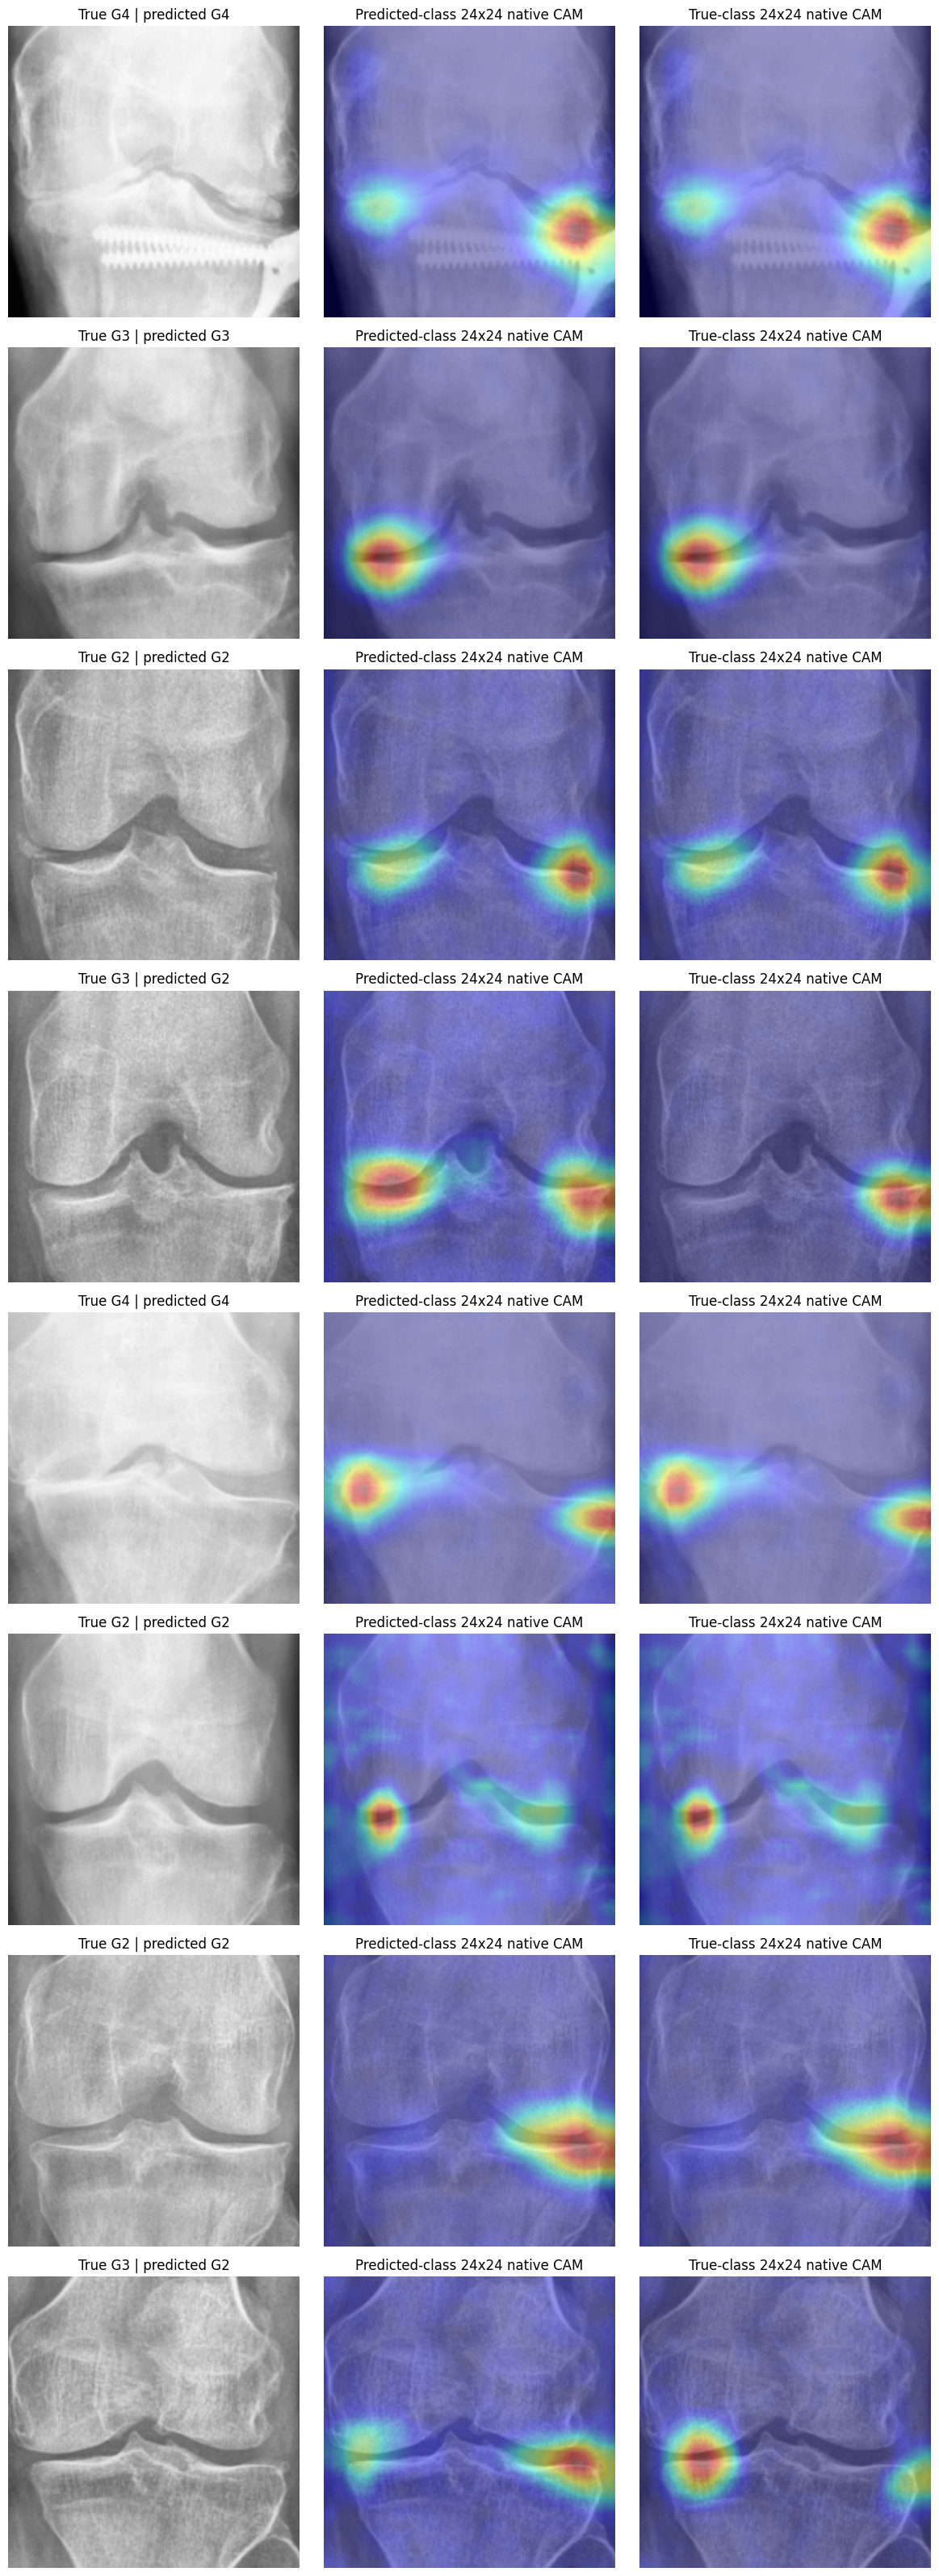

{
  "audited_cases": 227,
  "source_resolution": 24,
  "joint_energy": 0.7937939005415257,
  "border_energy": 0.11745558151281697,
  "lower_tibia_energy": 0.11490698088738914,
  "peak_inside_joint_rate": 0.9911894273127754
}


In [ ]:
def cam_geometry(cam):
    height, width = cam.shape
    joint = np.zeros((height, width), dtype=bool)
    joint[
        int(0.28 * height):int(0.72 * height),
        int(0.06 * width):int(0.94 * width),
    ] = True
    border = np.ones((height, width), dtype=bool)
    border[
        int(0.08 * height):int(0.92 * height),
        int(0.08 * width):int(0.92 * width),
    ] = False
    lower_tibia = np.zeros((height, width), dtype=bool)
    lower_tibia[int(0.72 * height):, :] = True
    total = float(cam.sum()) + 1e-8
    peak = np.unravel_index(np.argmax(cam), cam.shape)
    return {
        "joint_energy": float(cam[joint].sum()) / total,
        "border_energy": float(cam[border].sum()) / total,
        "lower_tibia_energy": float(cam[lower_tibia].sum()) / total,
        "peak_inside_joint": int(joint[peak]),
    }


rng = np.random.default_rng(SEED)
audit_indices = []
labels_array = np.asarray(validation_dataset.labels)
for grade in range(5):
    grade_indices = np.flatnonzero(labels_array == grade)
    rng.shuffle(grade_indices)
    audit_indices.extend(grade_indices[:min(50, len(grade_indices))].tolist())

cam_rows = []
cached_maps = {}
for index in tqdm.tqdm(audit_indices, desc="24x24 NATIVE CAM AUDIT"):
    tensor, true_grade, path = validation_dataset[index]
    batch = tensor[None].to(device)
    with torch.no_grad():
        logits = model(batch)
        predicted_grade = int(logits.argmax(1).item())
    predicted_cam, _ = model.native_cam(batch, [predicted_grade])
    true_cam, _ = model.native_cam(batch, [int(true_grade)])
    predicted_cam = predicted_cam[0].cpu().numpy()
    true_cam = true_cam[0].cpu().numpy()
    row = {
        "dataset_index": index,
        "path": path,
        "true_grade": int(true_grade),
        "predicted_grade": predicted_grade,
        **{
            f"predicted_{key}": value
            for key, value in cam_geometry(predicted_cam).items()
        },
        **{
            f"true_{key}": value
            for key, value in cam_geometry(true_cam).items()
        },
    }
    cam_rows.append(row)
    cached_maps[index] = (tensor, predicted_cam, true_cam)

with open(RUN_DIR / "native_cam_audit.csv", "w", newline="") as handle:
    writer = csv.DictWriter(handle, fieldnames=cam_rows[0].keys())
    writer.writeheader()
    writer.writerows(cam_rows)

cam_summary = {
    "audited_cases": len(cam_rows),
    "source_resolution": 24,
    "joint_energy": float(np.mean([
        row["predicted_joint_energy"] for row in cam_rows
    ])),
    "border_energy": float(np.mean([
        row["predicted_border_energy"] for row in cam_rows
    ])),
    "lower_tibia_energy": float(np.mean([
        row["predicted_lower_tibia_energy"] for row in cam_rows
    ])),
    "peak_inside_joint_rate": float(np.mean([
        row["predicted_peak_inside_joint"] for row in cam_rows
    ])),
}
with open(RUN_DIR / "native_cam_summary.json", "w") as handle:
    json.dump(cam_summary, handle, indent=2)

worst_cases = sorted(
    cam_rows,
    key=lambda row: (
        1 - row["predicted_peak_inside_joint"]
        + row["predicted_border_energy"]
        + row["predicted_lower_tibia_energy"]
    ),
    reverse=True,
)[:8]
mean = torch.tensor([0.485, 0.456, 0.406])[:, None, None]
std = torch.tensor([0.229, 0.224, 0.225])[:, None, None]
figure, axes = plt.subplots(len(worst_cases), 3, figsize=(12, 4 * len(worst_cases)))
for row_index, row in enumerate(worst_cases):
    tensor, predicted_cam, true_cam = cached_maps[row["dataset_index"]]
    display_image = (
        (tensor.cpu() * std + mean)
        .clamp(0, 1)
        .permute(1, 2, 0)
        .numpy()
    )
    axes[row_index, 0].imshow(display_image)
    axes[row_index, 0].set_title(
        f"True G{row['true_grade']} | predicted G{row['predicted_grade']}"
    )
    axes[row_index, 1].imshow(display_image)
    axes[row_index, 1].imshow(predicted_cam, cmap="jet", alpha=0.40)
    axes[row_index, 1].set_title("Predicted-class 24x24 native CAM")
    axes[row_index, 2].imshow(display_image)
    axes[row_index, 2].imshow(true_cam, cmap="jet", alpha=0.40)
    axes[row_index, 2].set_title("True-class 24x24 native CAM")
    for axis in axes[row_index]:
        axis.axis("off")
figure.tight_layout()
figure.savefig(RUN_DIR / "native_cam_worst_cases.png", dpi=180)
plt.show()
print(json.dumps(cam_summary, indent=2))

## Reproducible Run Report and Promotion Gate

The final report compares the candidate against the exact completed baseline.
Promotion requires the candidate to meet the baseline validation selection score,
joint energy, and border energy. Test metrics are reported but are deliberately
excluded from the promotion gate.

In [ ]:
validation_metrics = best_checkpoint["validation_metrics"]
validation_deltas = {
    key: float(validation_metrics[key] - BASELINE_VALIDATION[key])
    for key in BASELINE_VALIDATION
}
test_deltas = {
    key: float(test_metrics[key] - BASELINE_TEST[key])
    for key in BASELINE_TEST
}
cam_deltas = {
    key: float(cam_summary[key] - BASELINE_CAM[key])
    for key in ("joint_energy", "border_energy", "lower_tibia_energy", "peak_inside_joint_rate")
}
predictive_gate_passed = (
    validation_metrics["selection_score"]
    >= BASELINE_VALIDATION["selection_score"]
)
localization_gate_passed = (
    cam_summary["joint_energy"] >= BASELINE_CAM["joint_energy"]
    and cam_summary["border_energy"] <= BASELINE_CAM["border_energy"]
)
eligible_for_promotion = predictive_gate_passed and localization_gate_passed

comparison = {
    "baseline_run": "2026-07-23_01-25-36_772175_UTC_final_native_cam_ce",
    "candidate_run": RUN_TIMESTAMP,
    "baseline_validation": BASELINE_VALIDATION,
    "candidate_validation": validation_metrics,
    "validation_deltas": validation_deltas,
    "baseline_test": BASELINE_TEST,
    "candidate_test": test_metrics,
    "test_deltas": test_deltas,
    "baseline_cam": BASELINE_CAM,
    "candidate_cam": cam_summary,
    "cam_deltas": cam_deltas,
    "predictive_gate_passed": predictive_gate_passed,
    "localization_gate_passed": localization_gate_passed,
    "eligible_for_promotion": eligible_for_promotion,
}
with open(RUN_DIR / "baseline_comparison.json", "w") as handle:
    json.dump(comparison, handle, indent=2)

manifest = {
    "run_timestamp": RUN_TIMESTAMP,
    "run_directory": str(RUN_DIR),
    "model_name": "seresnext50_32x4d",
    "architecture": ARCHITECTURE,
    "loss": "cross_entropy",
    "ema_decay": EMA_DECAY,
    "input_resize": 400,
    "input_crop": 384,
    "batch_size": BATCH_SIZE,
    "sampler": "full_inverse_frequency",
    "canonicalize_laterality": True,
    "stages": [
        {"name": "warmup", "epochs": 5, "learning_rate": 3e-4},
        {"name": "coarse", "epochs": 15, "backbone_lr": 3e-5, "head_lr": 3e-4},
        {"name": "finetune", "epochs": 10, "learning_rate": 1e-5},
    ],
    "best_epoch": best_checkpoint["epoch"],
    "validation_metrics": validation_metrics,
    "test_metrics": test_metrics,
    "native_cam_summary": cam_summary,
    "promotion_gate": {
        "predictive": predictive_gate_passed,
        "localization": localization_gate_passed,
        "eligible": eligible_for_promotion,
    },
    "selected_checkpoint": str(best_path),
}
with open(RUN_DIR / "run_manifest.json", "w") as handle:
    json.dump(manifest, handle, indent=2)
(RUN_DIR / "SELECTED_CHECKPOINT.txt").write_text(str(best_path) + "\n")

report = f"""# SE-ResNeXt-50 Multiscale Native-CAM + EMA Run Report

| Field | Value |
| --- | --- |
| Run timestamp | {RUN_TIMESTAMP} |
| Architecture | `{ARCHITECTURE}` |
| Native-CAM source | 24x24 multiscale class maps |
| EMA decay | {EMA_DECAY} |
| Loss | Cross-entropy |
| Input | Resize 400, center/random crop 384 |
| Batch size | {BATCH_SIZE} |
| Sampler | Full inverse-frequency |
| Best epoch | {best_checkpoint['epoch']} |
| Selected checkpoint | `{best_path}` |

## Validation Selection Metrics

| QWK | Macro F1 | Macro Recall | Grade 1 Recall | AP | AUC | Selection |
| ---: | ---: | ---: | ---: | ---: | ---: | ---: |
| {validation_metrics['qwk']:.4f} | {validation_metrics['macro_f1']:.4f} | {validation_metrics['macro_recall']:.4f} | {validation_metrics['grade1_recall']:.4f} | {validation_metrics['macro_ap']:.4f} | {validation_metrics['macro_auc']:.4f} | {validation_metrics['selection_score']:.4f} |

## Locked Test Metrics

| Accuracy | QWK | Macro F1 | Grade 1 Recall | AP | AUC |
| ---: | ---: | ---: | ---: | ---: | ---: |
| {test_metrics['accuracy']:.4f} | {test_metrics['qwk']:.4f} | {test_metrics['macro_f1']:.4f} | {test_metrics['grade1_recall']:.4f} | {test_metrics['macro_ap']:.4f} | {test_metrics['macro_auc']:.4f} |

## Native-CAM Audit

| Cases | Source | Joint energy | Border energy | Lower-tibia energy | Peak inside joint |
| ---: | ---: | ---: | ---: | ---: | ---: |
| {cam_summary['audited_cases']} | {cam_summary['source_resolution']}x{cam_summary['source_resolution']} | {cam_summary['joint_energy']:.4f} | {cam_summary['border_energy']:.4f} | {cam_summary['lower_tibia_energy']:.4f} | {cam_summary['peak_inside_joint_rate']:.4f} |

## Promotion Gate

| Predictive gate | Localization gate | Eligible for promotion |
| --- | --- | --- |
| {predictive_gate_passed} | {localization_gate_passed} | {eligible_for_promotion} |

The promotion decision uses validation and CAM audit results only. Test metrics are
reported for documentation and do not influence checkpoint selection. The native
CAM remains model evidence rather than an expert-validated lesion segmentation.
"""
(RUN_DIR / "report.md").write_text(report, encoding="utf-8")
print(json.dumps(comparison, indent=2))
print(f"Report: {RUN_DIR / 'report.md'}")
print(f"Eligible for promotion: {eligible_for_promotion}")
print(f"All artifacts: {RUN_DIR}")

{
  "baseline_run": "2026-07-23_01-25-36_772175_UTC_final_native_cam_ce",
  "candidate_run": "2026-07-23_06-57-13_378879_UTC",
  "baseline_validation": {
    "qwk": 0.7873319830602099,
    "macro_f1": 0.6497842097059795,
    "grade1_recall": 0.41830065359477125,
    "macro_ap": 0.6915474596314173,
    "macro_auc": 0.8752130998574217,
    "selection_score": 0.7002724504801549
  },
  "candidate_validation": {
    "accuracy": 0.5423728813559322,
    "qwk": 0.7149523748641564,
    "macro_precision": 0.6138538109980834,
    "macro_recall": 0.6402788931699898,
    "macro_f1": 0.602845515140597,
    "grade1_recall": 0.6078431372549019,
    "macro_ap": 0.6572779580069203,
    "macro_auc": 0.857877043397805,
    "selection_score": 0.6728478018871995,
    "loss": 0.9884524762846945
  },
  "validation_deltas": {
    "qwk": -0.07237960819605349,
    "macro_f1": -0.046938694565382466,
    "grade1_recall": 0.18954248366013066,
    "macro_ap": -0.034269501624496934,
    "macro_auc": -0.01733605645961

In [ ]:
try:
    from google.colab import runtime
    print("All artifacts saved. Releasing the Colab runtime.")
    runtime.unassign()
except ImportError:
    print("Not running in Colab; runtime release skipped.")


All artifacts saved. Releasing the Colab runtime.
